In [4]:
import networkx as nx
import random
import numpy as np
import matplotlib.pyplot as plt

In [5]:
def generate_graph(n, m):
    return nx.gnm_random_graph(n, m)

In [6]:
def coloring_conflicts(G, coloring):
    conflicts = 0
    for u, v in G.edges():
        if coloring[u] == coloring[v]:
            conflicts += 1
    return conflicts

In [7]:
def random_coloring(G, num_colors):
    coloring = {}
    for node in G.nodes():
        coloring[node] = random.randint(0, num_colors-1)
    return coloring

In [42]:
def chromatic_optimiser_neighbourhood(G, coloring, num_colors, hops=1):
    for node in G.nodes():
        # Get all nodes within hops distance of current node
        # start with the node itself
        neighbourhood = {node}
        current_hop = {node}

        for _ in range(hops):
            # temporarily store nodes we add in this iteration.
            next_hop = set()

            # for every node at the curr dist, add all neighbours
            for n in current_hop:
                next_hop.update(G.neighbors(n))

            # add next hop nodes to neighbour
            next_hop -= neighbourhood
            neighbourhood.update(next_hop)
            current_hop = next_hop

        assert neighbourhood == set(nx.single_source_shortest_path_length(G, node, cutoff=hops).keys())

        # get colors of neighbourhood
        neighbour_colors = set(coloring[n] for n in neighbourhood if n != node)

        # loop through all colors currently being used by neighbours in N hops
        # give node a color that is not being used by neighbourhood nodes (if possible)
        for color in range(num_colors):
            if color not in neighbour_colors:
                coloring[node] = color
                break
    return coloring

In [105]:
def run_trials(hops_values, n, m):
    # Initialize dictionaries to store all trial results
    initial_results = {h: [] for h in hops_values}
    optimised_results = {h: [] for h in hops_values}
    reduction_results = {h: [] for h in hops_values}

    for _ in range(num_trials):
        G = generate_graph(n, m)
        coloring = random_coloring(G, num_colors)
        initial_conflicts = coloring_conflicts(G, coloring)

        for hops in hops_values:
            test_coloring = coloring.copy()
            optimised_coloring = chromatic_optimiser_neighbourhood(G, test_coloring, num_colors, hops)
            optimised_conflicts = coloring_conflicts(G, optimised_coloring)
            reduction = initial_conflicts - optimised_conflicts

            # Store each trial
            initial_results[hops].append(initial_conflicts)
            optimised_results[hops].append(optimised_conflicts)
            reduction_results[hops].append(reduction)

    return initial_results, optimised_results, reduction_results

# Experiment 1

In [55]:
num_trials = 200
n = 30
m = 50
num_colors = 5

In [101]:
hops_values = [1, 2, 3]

In [102]:
initial_results, optimised_results, reduction_results = run_trials(hops_values, n, m)
# Compute averages
avg_initial = [np.mean(initial_results[h]) for h in hops_values]
avg_optimised = [np.mean(optimised_results[h]) for h in hops_values]
avg_reductions = [np.mean(reduction_results[h]) for h in hops_values]

std_reductions = [np.std(reduction_results[h]) for h in hops_values]
std_initial = [np.std(initial_results[h]) for h in hops_values]
std_optimised = [np.std(optimised_results[h]) for h in hops_values]

print("Average Initial Conflicts:", avg_initial)
print("Average Optimised Conflicts:", avg_optimised)
print("Average Conflict Reductions:", avg_reductions)

Average Initial Conflicts: [np.float64(15.76), np.float64(15.76), np.float64(15.76)]
Average Optimised Conflicts: [np.float64(0.77), np.float64(14.8), np.float64(15.73)]
Average Conflict Reductions: [np.float64(14.99), np.float64(0.96), np.float64(0.03)]


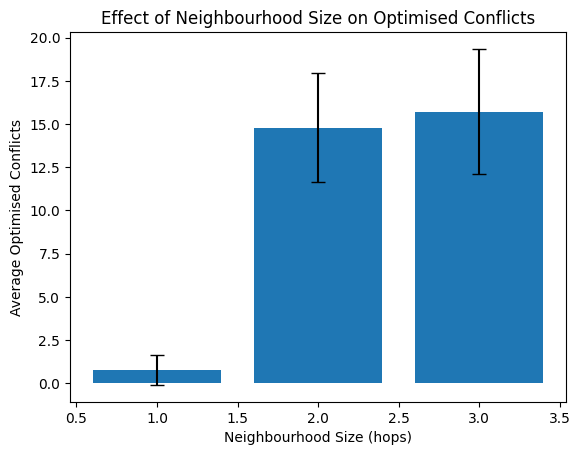

In [103]:
plt.bar(hops_values, avg_optimised, yerr=std_optimised, capsize=5)

plt.xlabel("Neighbourhood Size (hops)")
plt.ylabel("Average Optimised Conflicts")
plt.title("Effect of Neighbourhood Size on Optimised Conflicts")

plt.show()

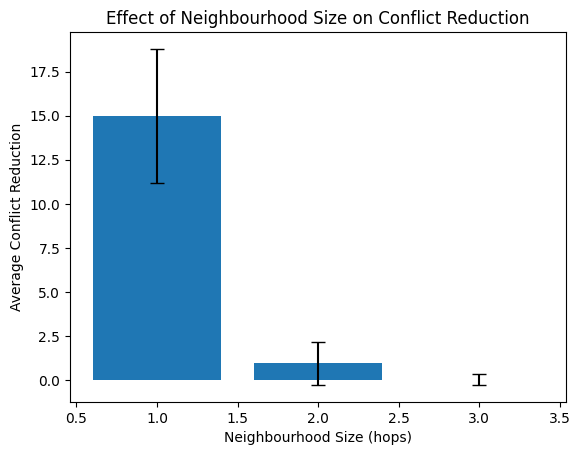

In [104]:
plt.bar(hops_values, avg_reductions, yerr=std_reductions, capsize=5)

plt.xlabel("Neighbourhood Size (hops)")
plt.ylabel("Average Conflict Reduction")
plt.title("Effect of Neighbourhood Size on Conflict Reduction")

plt.show()

# Experiment 2
Examine the affect of graph density with neighbourhood size

In [92]:
densities = [20, 40, 60, 80]
hops_values = [1]
n = 30

# Store results for each density
density_results = {}

for m in densities:

    initial_results, optimised_results, reduction_results = run_trials(hops_values, n, m)

    # Compute averages
    avg_initial = [np.mean(initial_results[h]) for h in hops_values]
    avg_optimised = [np.mean(optimised_results[h]) for h in hops_values]
    avg_reductions = [np.mean(reduction_results[h]) for h in hops_values]

    initial_results, optimised_results, reduction_results = run_trials(hops_values, n, m)

    density_results[m] = {
        'avg_initial': np.mean(initial_results[1]),
        'avg_optimised': np.mean(optimised_results[1]),
        'avg_reductions': np.mean(reduction_results[1]),
        'initial_all': initial_results[1],
        'optimised_all': optimised_results[1],
        'reduction_all': reduction_results[1]
    }

In [93]:
print("Density Experiment Results:")
for m, res in density_results.items():
    print(f"Edges: {m} | Initial: {res['avg_initial']:.2f} | "
          f"Optimised: {res['avg_optimised']:.2f} | "
          f"Reduction: {res['avg_reductions']:.2f}")

Density Experiment Results:
Edges: 20 | Initial: 4.13 | Optimised: 0.00 | Reduction: 4.13
Edges: 40 | Initial: 8.18 | Optimised: 0.01 | Reduction: 8.18
Edges: 60 | Initial: 11.93 | Optimised: 0.10 | Reduction: 11.83
Edges: 80 | Initial: 15.84 | Optimised: 0.68 | Reduction: 15.16


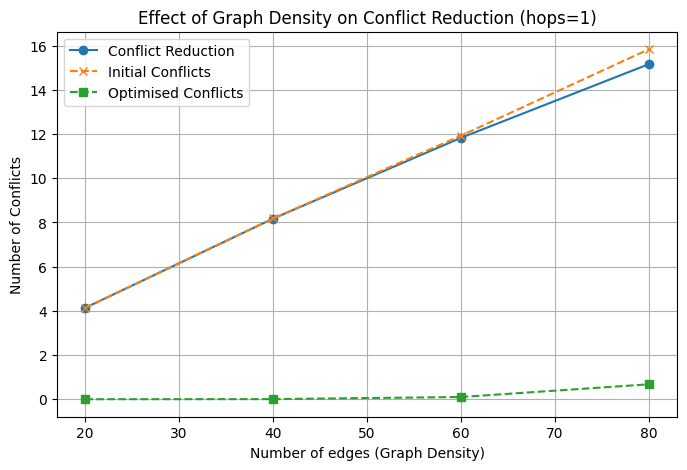

In [96]:
densities = list(density_results.keys())

# Extract averages
avg_initial = [density_results[m]['avg_initial'] for m in densities]
avg_optimised = [density_results[m]['avg_optimised'] for m in densities]
avg_reductions = [density_results[m]['avg_reductions'] for m in densities]

plt.figure(figsize=(8,5))
plt.plot(densities, avg_reductions, marker='o', linestyle='-', label='Conflict Reduction')
plt.plot(densities, avg_initial, marker='x', linestyle='--', label='Initial Conflicts')
plt.plot(densities, avg_optimised, marker='s', linestyle='--', label='Optimised Conflicts')

plt.xlabel("Number of edges (Graph Density)")
plt.ylabel("Number of Conflicts")
plt.title("Effect of Graph Density on Conflict Reduction (hops=1)")
plt.legend()
plt.grid(True)
plt.show()

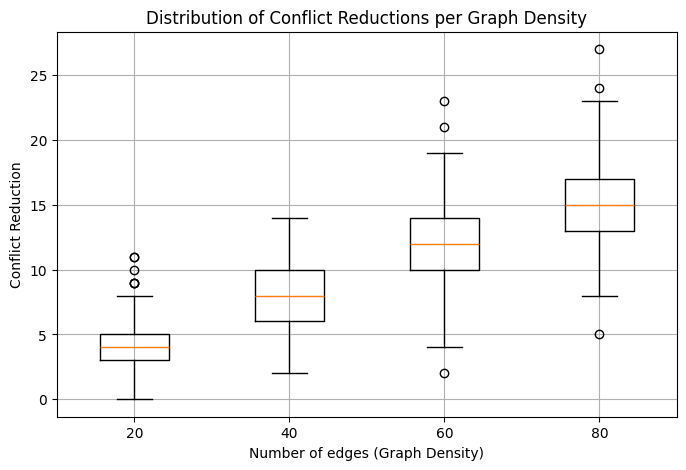

In [97]:
# Collect trial reductions for boxplot
reduction_data = [density_results[m]['reduction_all'] for m in densities]

plt.figure(figsize=(8,5))
plt.boxplot(reduction_data, tick_labels=densities)
plt.xlabel("Number of edges (Graph Density)")
plt.ylabel("Conflict Reduction")
plt.title("Distribution of Conflict Reductions per Graph Density")
plt.grid(True)
plt.show()

# Experiment 3

In [107]:
num_trials = 5
num_colors = 5
hops_values = [1, 2, 3]
graph_sizes = [20, 30, 50, 80]
density_factor = 2  # edges per node multiplier

# Dictionaries to store results for plotting
results_initial = {h: [] for h in hops_values}
results_optimised = {h: [] for h in hops_values}
results_reduction = {h: [] for h in hops_values}

# Loop over graph sizes
for n in graph_sizes:
    m = n * density_factor  # scale edges with graph size

    # Run trials using your function
    initial_res, optimised_res, reduction_res = run_trials(hops_values, n, m)

    # Store averages per hops
    for hops in hops_values:
        results_initial[hops].append(np.mean(initial_res[hops]))
        results_optimised[hops].append(np.mean(optimised_res[hops]))
        results_reduction[hops].append(np.mean(reduction_res[hops]))

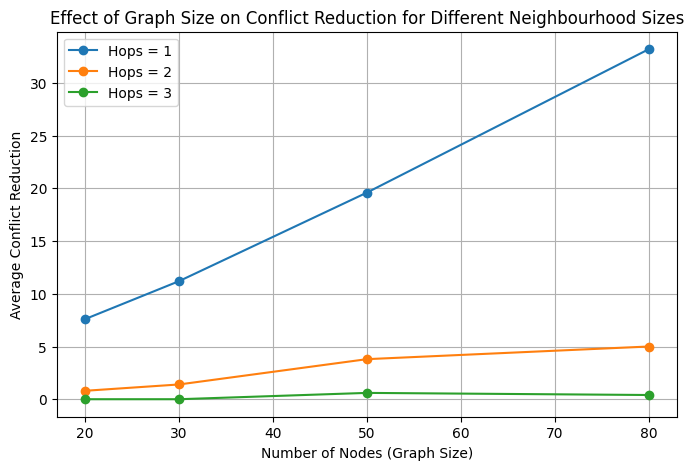

In [108]:
plt.figure(figsize=(8,5))
for hops in hops_values:
    plt.plot(graph_sizes, results_reduction[hops], marker='o', label=f'Hops = {hops}')

plt.xlabel("Number of Nodes (Graph Size)")
plt.ylabel("Average Conflict Reduction")
plt.title("Effect of Graph Size on Conflict Reduction for Different Neighbourhood Sizes")
plt.grid(True)
plt.legend()
plt.show()

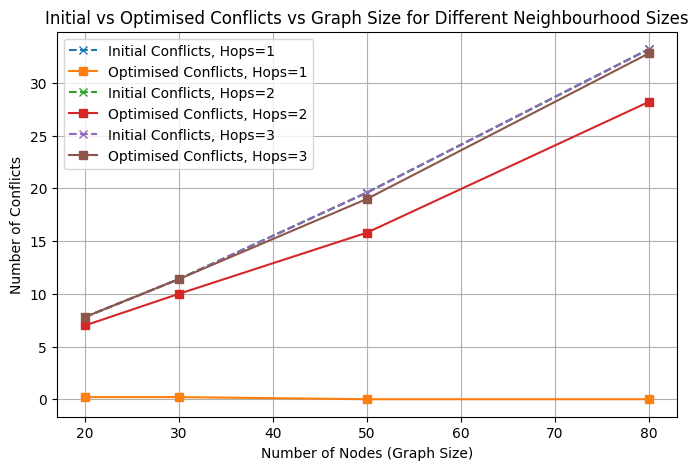

In [109]:
plt.figure(figsize=(8,5))
for hops in hops_values:
    plt.plot(graph_sizes, results_initial[hops], marker='x', linestyle='--', label=f'Initial Conflicts, Hops={hops}')
    plt.plot(graph_sizes, results_optimised[hops], marker='s', linestyle='-', label=f'Optimised Conflicts, Hops={hops}')

plt.xlabel("Number of Nodes (Graph Size)")
plt.ylabel("Number of Conflicts")
plt.title("Initial vs Optimised Conflicts vs Graph Size for Different Neighbourhood Sizes")
plt.grid(True)
plt.legend()
plt.show()

In [111]:
print("Graph Size Experiment Results:")

for hops in hops_values:
    print(f"\n--- Hops = {hops} ---")
    for i, n in enumerate(graph_sizes):
        print(f"Nodes: {n} | Initial: {results_initial[hops][i]:.2f} | "
              f"Optimised: {results_optimised[hops][i]:.2f} | "
              f"Reduction: {results_reduction[hops][i]:.2f}")

Graph Size Experiment Results:

--- Hops = 1 ---
Nodes: 20 | Initial: 7.80 | Optimised: 0.20 | Reduction: 7.60
Nodes: 30 | Initial: 11.40 | Optimised: 0.20 | Reduction: 11.20
Nodes: 50 | Initial: 19.60 | Optimised: 0.00 | Reduction: 19.60
Nodes: 80 | Initial: 33.20 | Optimised: 0.00 | Reduction: 33.20

--- Hops = 2 ---
Nodes: 20 | Initial: 7.80 | Optimised: 7.00 | Reduction: 0.80
Nodes: 30 | Initial: 11.40 | Optimised: 10.00 | Reduction: 1.40
Nodes: 50 | Initial: 19.60 | Optimised: 15.80 | Reduction: 3.80
Nodes: 80 | Initial: 33.20 | Optimised: 28.20 | Reduction: 5.00

--- Hops = 3 ---
Nodes: 20 | Initial: 7.80 | Optimised: 7.80 | Reduction: 0.00
Nodes: 30 | Initial: 11.40 | Optimised: 11.40 | Reduction: 0.00
Nodes: 50 | Initial: 19.60 | Optimised: 19.00 | Reduction: 0.60
Nodes: 80 | Initial: 33.20 | Optimised: 32.80 | Reduction: 0.40
